# Membangun Penanda NER Sendiri Menggunakan pycrfsuite

**Pengenalan Entitas Bernama (NER)** adalah tugas pelabelan urutan yang menetapkan label ke setiap token dalam sebuah kalimat. Tujuannya adalah mengidentifikasi rentang teks yang merujuk ke entitas dunia nyata seperti orang, organisasi, lokasi, dan kategori spesifik domain lainnya.

Karena NER bergantung pada konteks di sekitar kata yang berdekatan, tugas ini lebih baik dimodelkan sebagai masalah urutan daripada klasifikasi per-kata yang independen. Misalnya, dalam kalimat *"Budi tinggal di Jakarta"*, kata *"Jakarta"* hanya dapat dikenali sebagai lokasi ketika kata-kata sekitarnya juga dipertimbangkan.

Dalam notebook ini, kita akan membangun penanda NER khusus menggunakan Conditional Random Fields (CRF) dan melatihnya dengan `pycrfsuite`. Model akan dievaluasi menggunakan dataset NER Indonesia.

## Memuat Dataset

NER adalah masalah pelabelan urutan, sehingga model memerlukan dataset berlabel di mana setiap token dipasangkan dengan tag entitasnya. Dataset yang digunakan dalam notebook ini berasal dari versi yang telah diproses dari **INDONLU corpus**, yang tersedia di [indonlu/nerp_ner-prosa](https://github.com/IndoNLP/indonlu/tree/master/dataset/nerp_ner-prosa).

Repository mencakup dataset dalam bentuk teks, sehingga dapat dimuat langsung dengan `pandas`. Setiap file diorganisir sebagai pasangan token-tag, dan baris kosong digunakan untuk memisahkan satu kalimat dari yang lain. Misalnya, fragmen pendek seperti `Jakarta    B-LOC` atau `Budi    B-PER` mewakili satu token tunggal dan labelnya.

Pada sel berikutnya, kami akan memuat file pelatihan `train-70.txt` dan file pengujian `test-data.txt` ke dalam DataFrame yang dapat digunakan untuk praproses dan pelatihan model.

In [1]:
#!pip install scikit-learn==0.24.0

### Langkah 1: Mempersiapkan Lingkungan dan Memuat Data

Pada bagian ini, kita akan menyiapkan lingkungan Python dengan mengimpor library yang diperlukan dan mendefinisikan fungsi untuk memuat data NER. Fungsi `load_ner_data_from_txt()` akan membaca file teks yang berisi pasangan token-tag dan mengubahnya menjadi DataFrame pandas. DataFrame ini akan memudahkan kami untuk melakukan manipulasi data dan analisis lebih lanjut.

In [2]:
import pandas as pd



import pandas as pd
import numpy as np

def load_ner_data_from_txt(file_path, sep="\t", encoding="utf-8"):
    """
    Load NER data from a text file into a pandas DataFrame.
    
    Parameters:
    file_path (str): Path to the text file containing NER data
    sep (str): Separator used in the text file (default: tab)
    encoding (str): File encoding (default: utf-8)
    
    Returns:
    pd.DataFrame: DataFrame with 'word' and 'tag' columns
    """
    # Load the file with pandas, keeping blank lines
    df = pd.read_csv(
        file_path, 
        sep=sep, 
        skip_blank_lines=False, 
        encoding=encoding,
        names=['word', 'tag'],  
        header=None,           
        quoting=3              
    )
    
    return df

dfpos = load_ner_data_from_txt("ner/train-70.txt")## TODO: Implementasikan fungsi load_ner_data_from_txt untuk memuat data pelatihan yaitu train-70.txt
dftest = load_ner_data_from_txt("ner/test-data.txt")## TODO: Implementasikan fungsi load_ner_data_from_txt untuk memuat data pengujian yaitu test-data.txt

print(dfpos.head(10))

          word      tag
0      JAKARTA        O
1            ,        O
2       KOMPAS        O
3            —        O
4    Perangkat  B-ISSUE
5         suar  I-ISSUE
6         yang  I-ISSUE
7  menunjukkan  I-ISSUE
8       lokasi  I-ISSUE
9      pesawat  I-ISSUE


In [3]:
dfpos.shape

(596101, 2)

### Langkah 2: Memeriksa Statistik Dataset

Sebelum kita memproses data lebih lanjut, penting untuk memahami karakteristik dataset kita. Pada bagian ini, kita akan memeriksa dimensi dataset (jumlah baris dan kolom) serta distribusi label entitas. Informasi ini membantu kita memahami seimbang atau tidaknya dataset dan jenis entitas apa yang paling sering muncul dalam data pelatihan.

In [4]:
dfpos.tag.value_counts()

tag
O                434030
I-STATEMENT       83462
I-ISSUE           14167
I-AFFILIATION      3202
I-DATETIME         3099
B-STATEMENT        2887
L-STATEMENT        2887
I-ROLE             2303
I-EVENT            2090
U-CUE              1917
L-PERSON           1615
B-PERSON           1615
U-PERSONCOREF      1597
B-ROLE             1239
L-ROLE             1239
L-AFFILIATION      1157
B-AFFILIATION      1157
U-CUECOREF          977
I-PERSON            849
B-ISSUE             712
L-ISSUE             712
U-ROLE              570
B-EVENT             545
L-EVENT             545
L-DATETIME          518
B-DATETIME          518
I-LOCATION          286
U-LOCATION          160
U-AFFILIATION       151
U-PERSON            151
L-LOCATION          117
B-LOCATION          117
B-PERSONCOREF        95
L-PERSONCOREF        95
I-PERSONCOREF        66
U-EVENT               3
Name: count, dtype: int64

In [5]:
dfpos['sentence'] = dfpos.isnull().all(axis=1).cumsum()
dftest['sentence'] = dftest.isnull().all(axis=1).cumsum()

### Langkah 3: Mengelompokkan Token Berdasarkan Kalimat

Dalam dataset NER, token-token diorganisir berdasarkan kalimat. Baris kosong dalam file teks menandakan pemisah antara kalimat. Pada langkah ini, kita membuat kolom baru bernama `sentence` yang memberikan nomor identifikasi unik untuk setiap kalimat. Kolom ini sangat penting karena model CRF bekerja pada tingkat kalimat, bukan pada token individual, dan kita perlu mengetahui token mana yang milik kalimat yang sama saat mengekstrak fitur dan melatih model.

In [6]:
dfpos["pos"] = ""
dftest["pos"] = ""



def add_pos_tags(df, use_pos=True, dataset_name="dataset", force_reprocess=False):
    """
    Add POS tags to dataframe using spaCy's Indonesian model with CSV caching.

    Parameters:
    df (pd.DataFrame): DataFrame with 'word' and 'sentence' columns
    use_pos (bool): Whether to actually use POS tagging or leave empty
    dataset_name (str): Name to use for the cached CSV file
    force_reprocess (bool): Whether to force reprocessing even if cache exists

    Returns:
    tuple: (DataFrame with 'pos' column filled, POS stats DataFrame)
    """
    if not use_pos:
        print("Skipping POS tagging as use_pos=False")
        return df, None

    csv_filename = f"{dataset_name}_with_pos.csv"

    if not force_reprocess and os.path.exists(csv_filename):
        print(f"Loading POS tags from cached file: {csv_filename}")
        try:
            df_cached = pd.read_csv(csv_filename)
            if (
                "word" in df_cached.columns
                and "pos" in df_cached.columns
                and "tag" in df_cached.columns
            ):
                print("Successfully loaded cached POS tags")
                return df_cached, None
            else:
                print("Cached file exists but has incorrect structure. Reprocessing...")
        except Exception as e:
            print(f"Error loading cached file: {e}. Reprocessing...")

    print(f"Processing POS tags for {dataset_name}...")

    pos_stats = {
        "sentence_id": [],
        "total_tokens": [],
        "matched_tokens": [],
        "unmatched_tokens": [],
        "match_rate": [],
    }

    try:
        nlp = spacy.load("id_nusantara")
        print("Successfully loaded id_nusantara model")
    except:
        print("Trying to download id_nusantara model...")
        spacy.cli.download("id_nusantara")
        nlp = spacy.load("id_nusantara")

    sentence_groups = df.groupby("sentence")

    for sentence_id, group in sentence_groups:
        if group.isnull().all(axis=1).any():
            continue

        words = group["word"].fillna("").tolist()
        sentence_text = " ".join(words)

        if not sentence_text.strip():
            continue

        doc = nlp(sentence_text)## TODO: Implementasikan pemrosesan POS tagging menggunakan spaCy untuk setiap kalimat dalam dataframe df

        total_tokens = len(group)
        matched_tokens = 0
        unmatched_tokens = 0

        token_index = 0
        for i, row_idx in enumerate(group.index):
            if i < len(doc) and token_index < len(doc):
                if (
                    str(doc[token_index]).lower()
                    == str(df.loc[row_idx, "word"]).lower()
                ):
                    df.loc[row_idx, "pos"] = doc[token_index].pos_
                    token_index += 1
                    matched_tokens += 1
                else:
                    df.loc[row_idx, "pos"] = doc[i].pos_ if i < len(doc) else ""
                    unmatched_tokens += 1
            else:
                df.loc[row_idx, "pos"] = ""
                unmatched_tokens += 1
        pos_stats["sentence_id"].append(sentence_id)
        pos_stats["total_tokens"].append(total_tokens)
        pos_stats["matched_tokens"].append(matched_tokens)
        pos_stats["unmatched_tokens"].append(unmatched_tokens)
        pos_stats["match_rate"].append(
            matched_tokens / total_tokens if total_tokens > 0 else 0
        )

    # Create DataFrame with POS tagging statistics
    pos_stats_df = pd.DataFrame(pos_stats)

    # Print summary statistics
    print(f"POS Tagging Summary:")
    print(f"Total tokens processed: {pos_stats_df['total_tokens'].sum()}")
    print(f"Successfully matched tokens: {pos_stats_df['matched_tokens'].sum()}")
    print(
        f"Match rate: {pos_stats_df['matched_tokens'].sum() / pos_stats_df['total_tokens'].sum():.2%}"
    )

    pos_distribution = df[df["pos"] != ""]["pos"].value_counts().reset_index()
    pos_distribution.columns = ["POS tag", "Count"]
    pos_distribution["Percentage"] = (
        pos_distribution["Count"] / pos_distribution["Count"].sum() * 100
    )
    print("\nPOS tag distribution (top 5):")
    print(pos_distribution.head(5))

    print(f"Saving processed data to {csv_filename} for future use")
    df.to_csv(csv_filename, index=False)

    return df, pos_stats_df




### Langkah 4: Menambahkan Tag Part-of-Speech (POS)

Selain fitur bentuk kata, model CRF juga memerlukan informasi tentang jenis kata (Part-of-Speech / POS). Fitur POS seperti NOUN (kata benda), VERB (kata kerja), PROPN (kata benda proper), dll., dapat membantu model mengidentifikasi pola linguistik yang terkait dengan entitas bernama. Misalnya, lokasi sering kali dimulai dengan kata benda proper (PROPN).

Fungsi `add_pos_tags()` menggunakan model spaCy Indonesian (`id_nusantara`) untuk menambahkan tag POS ke setiap token dalam dataset. Fungsi ini juga menyimpan hasil ke dalam file CSV agar tidak perlu diproses ulang setiap kali notebook dijalankan.

In [7]:
import os
!pip install numpy==1.26.4
import spacy

use_pos_tagging = True  
force_reprocess = False  
print("Processing training data...")

dfpos, train_pos_stats = add_pos_tags(
    dfpos,
    use_pos=use_pos_tagging,
    dataset_name="train",
    force_reprocess=force_reprocess
)## TODO: Implementasikan pemanggilan fungsi add_pos_tags untuk memproses data pelatihan dfpos dengan parameter yang sesuai

print("Processing test data...")
dftest, test_pos_stats = add_pos_tags(
    dftest,
    use_pos=use_pos_tagging,
    dataset_name="test",
    force_reprocess=force_reprocess
)## TODO: Implementasikan pemanggilan fungsi add_pos_tags untuk memproses data pengujian dftest dengan parameter yang sesuai

if use_pos_tagging and train_pos_stats is not None:
    print("\nPOS tagging match rate distribution:")
    train_pos_stats["match_rate"].describe()

# Reorder columns
dfpos = dfpos[["word", "pos", "tag", "sentence"]]
dftest = dftest[["word", "pos", "tag", "sentence"]]
dfpos.head(10)


Defaulting to user installation because normal site-packages is not writeable
Processing training data...
Processing POS tags for train...


/opt/tljh/user/envs/nlp/lib/python3.10/site-packages/spacy/util.py:971: UserWarning: [W095] Model 'id_nusantara' (1.0) was trained with spaCy v3.6.1 and may not be 100% compatible with the current version (3.8.14). If you see errors or degraded performance, download a newer compatible model or retrain your custom model with the current spaCy version. For more details and available updates, run: python -m spacy validate
  warnings.warn(warn_msg)


Successfully loaded id_nusantara model
POS Tagging Summary:
Total tokens processed: 596100
Successfully matched tokens: 46
Match rate: 0.01%

POS tag distribution (top 5):
  POS tag   Count  Percentage
0    NOUN  164830   27.651401
1   PUNCT   91939   15.423419
2   PROPN   91802   15.400436
3    VERB   63074   10.581111
4     ADP   45300    7.599396
Saving processed data to train_with_pos.csv for future use
Processing test data...
Processing POS tags for test...


/opt/tljh/user/envs/nlp/lib/python3.10/site-packages/spacy/util.py:971: UserWarning: [W095] Model 'id_nusantara' (1.0) was trained with spaCy v3.6.1 and may not be 100% compatible with the current version (3.8.14). If you see errors or degraded performance, download a newer compatible model or retrain your custom model with the current spaCy version. For more details and available updates, run: python -m spacy validate
  warnings.warn(warn_msg)


Successfully loaded id_nusantara model
POS Tagging Summary:
Total tokens processed: 102195
Successfully matched tokens: 37
Match rate: 0.04%

POS tag distribution (top 5):
  POS tag  Count  Percentage
0    NOUN  28335   27.726405
1   PROPN  16668   16.309996
2   PUNCT  15830   15.489995
3    VERB  10683   10.453545
4     ADP   7694    7.528744
Saving processed data to test_with_pos.csv for future use

POS tagging match rate distribution:


,word,pos,tag,sentence
0,JAKARTA,PROPN,O,0
1,",",PUNCT,O,0
2,KOMPAS,PROPN,O,0
3,—,PUNCT,O,0
4,Perangkat,NOUN,B-ISSUE,0
5,suar,ADJ,I-ISSUE,0
6,yang,PRON,I-ISSUE,0
7,menunjukkan,VERB,I-ISSUE,0
8,lokasi,NOUN,I-ISSUE,0
9,pesawat,NOUN,I-ISSUE,0


In [8]:
class getsentence(object):
    def __init__(self, data):
        self.n_sent = 1.0
        self.data = data
        self.empty = False
        
        def agg_func(s):
            words = s["word"].values.tolist()
            pos = s["pos"].values.tolist()
            tags = s["tag"].values.tolist()
            return [(w, p, t) for w, p, t in zip(words, pos, tags)]
            
        self.grouped = self.data.groupby("sentence").apply(agg_func)
        self.sentences = [s for s in self.grouped]


### Langkah 5: Mengubah Format Data

Model CRF dari pycrfsuite bekerja dengan data dalam format urutan kalimat di mana setiap kalimat adalah daftar tuple (token, POS, label). Kelas `getsentence` mengubah DataFrame pandas menjadi format ini dengan mengelompokkan token berdasarkan nomor kalimat. Hasilnya adalah struktur data yang mudah diproses oleh model CRF.

In [9]:
getter = getsentence(dfpos) ## TODO: Implementasikan pemanggilan kelas getsentence untuk memproses dataframe dfpos
testGetter = getsentence(dftest)## TODO: Implementasikan pemanggilan kelas getsentence untuk memproses dataframe dftest
getter.sentences[0:5]

/tmp/ipykernel_4171714/1730131725.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  self.grouped = self.data.groupby("sentence").apply(agg_func)
/tmp/ipykernel_4171714/1730131725.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  self.grouped = self.data.groupby("sentence").apply(agg_func)


[[('JAKARTA', 'PROPN', 'O'),
  (',', 'PUNCT', 'O'),
  ('KOMPAS', 'PROPN', 'O'),
  ('—', 'PUNCT', 'O'),
  ('Perangkat', 'NOUN', 'B-ISSUE'),
  ('suar', 'ADJ', 'I-ISSUE'),
  ('yang', 'PRON', 'I-ISSUE'),
  ('menunjukkan', 'VERB', 'I-ISSUE'),
  ('lokasi', 'NOUN', 'I-ISSUE'),
  ('pesawat', 'NOUN', 'I-ISSUE'),
  ('atau', 'CCONJ', 'I-ISSUE'),
  ('emergency', 'NOUN', 'I-ISSUE'),
  ('locator', 'NOUN', 'I-ISSUE'),
  ('transmitter', 'NOUN', 'I-ISSUE'),
  ('pada', 'ADP', 'I-ISSUE'),
  ('pesawat', 'NOUN', 'I-ISSUE'),
  ('Sriwijaya', 'PROPN', 'I-ISSUE'),
  ('Air', 'NOUN', 'I-ISSUE'),
  ('dengan', 'ADP', 'I-ISSUE'),
  ('nomor', 'NOUN', 'I-ISSUE'),
  ('penerbangan', 'NOUN', 'I-ISSUE'),
  ('SJ', 'PROPN', 'I-ISSUE'),
  ('-', 'PUNCT', 'I-ISSUE'),
  ('182', 'NUM', 'I-ISSUE'),
  ('rute', 'NOUN', 'I-ISSUE'),
  ('Jakarta', 'PROPN', 'I-ISSUE'),
  ('-', 'PUNCT', 'I-ISSUE'),
  ('Pontianak', 'PROPN', 'I-ISSUE'),
  (',', 'PUNCT', 'I-ISSUE'),
  ('yang', 'PRON', 'I-ISSUE'),
  ('hilang', 'VERB', 'I-ISSUE'),
  ('konta

In [10]:
len(getter.sentences)

29252

In [11]:
train_sentences = getter.sentences[0:10000]
test_sentences = testGetter.sentences[0:10000]
test_sentences[0:5]

[[('JAKARTA', 'PROPN', 'O'),
  (',', 'PUNCT', 'O'),
  ('KOMPAS', 'PROPN', 'O'),
  ('—', 'PUNCT', 'O'),
  ('Seorang', 'DET', 'B-ISSUE'),
  ('perempuan', 'NOUN', 'I-ISSUE'),
  ('34', 'NUM', 'I-ISSUE'),
  ('tahun', 'NOUN', 'I-ISSUE'),
  ('berinisial', 'NOUN', 'I-ISSUE'),
  ('RCD', 'PROPN', 'I-ISSUE'),
  ('ditemukan', 'VERB', 'I-ISSUE'),
  ('tidak', 'PART', 'I-ISSUE'),
  ('bernyawa', 'VERB', 'I-ISSUE'),
  ('di', 'ADP', 'I-ISSUE'),
  ('sebuah', 'DET', 'I-ISSUE'),
  ('kamar', 'NOUN', 'I-ISSUE'),
  ('hotel', 'NOUN', 'I-ISSUE'),
  ('di', 'ADP', 'I-ISSUE'),
  ('kawasan', 'NOUN', 'I-ISSUE'),
  ('Mangga', 'PROPN', 'I-ISSUE'),
  ('Besar', 'PROPN', 'I-ISSUE'),
  (',', 'PUNCT', 'I-ISSUE'),
  ('Kecamatan', 'PROPN', 'I-ISSUE'),
  ('Tamansari', 'PROPN', 'I-ISSUE'),
  (',', 'PUNCT', 'I-ISSUE'),
  ('Jakarta', 'PROPN', 'I-ISSUE'),
  ('Barat', 'PROPN', 'I-ISSUE'),
  (',', 'PUNCT', 'I-ISSUE'),
  ('Sabtu', 'PROPN', 'I-ISSUE'),
  ('(', 'PUNCT', 'I-ISSUE'),
  ('19', 'NUM', 'I-ISSUE'),
  ('/', 'PUNCT', 'I-ISSUE

In [12]:
def word2features(sent, i):
    word = sent[i][0]
    postag = sent[i][1]

    if isinstance(word, float) or word is None:
        word = ""
    if isinstance(postag, float) or postag is None:
        postag = ""

    features = [
        "bias",
        "word.lower=" + word.lower(),
        "word[-3:]=" + word[-3:] if len(word) >= 3 else "word[-3:]=",
        "word[-2:]=" + word[-2:] if len(word) >= 2 else "word[-2:]=",
        "word.isupper=%s" % word.isupper(),
        "word.istitle=%s" % word.istitle(),
        "word.isdigit=%s" % word.isdigit(),
        "postag=" + postag,
        "postag[:2]=" + postag[:2] if len(postag) >= 2 else "postag[:2]=",
    ]

    if i > 0:
        word1 = sent[i - 1][0]
        postag1 = sent[i - 1][1]

        # Handle NaN or None values for previous word
        if isinstance(word1, float) or word1 is None:
            word1 = ""
        if isinstance(postag1, float) or postag1 is None:
            postag1 = ""

        features.extend(
            [
                "-1:word.lower=" + word1.lower(),
                "-1:word.istitle=%s" % word1.istitle(),
                "-1:word.isupper=%s" % word1.isupper(),
                "-1:postag=" + postag1,
                "-1:postag[:2]=" + postag1[:2]
                if len(postag1) >= 2
                else "-1:postag[:2]=",
            ]
        )
    else:
        features.append("BOS")

    if i < len(sent) - 1:
        word1 = sent[i + 1][0]
        postag1 = sent[i + 1][1]

        # Handle NaN or None values for next word
        if isinstance(word1, float) or word1 is None:
            word1 = ""
        if isinstance(postag1, float) or postag1 is None:
            postag1 = ""

        features.extend(
            [
                "+1:word.lower=" + word1.lower(),
                "+1:word.istitle=%s" % word1.istitle(),
                "+1:word.isupper=%s" % word1.isupper(),
                "+1:postag=" + postag1,
                "+1:postag[:2]=" + postag1[:2]
                if len(postag1) >= 2
                else "+1:postag[:2]=",
            ]
        )
    else:
        features.append("EOS")

    return features


def sent2features(sent):
    return [word2features(sent, i) for i in range(len(sent))]


def sent2labels(sent):
    return [label for token, postag, label in sent]


def sent2tokens(sent):
    return [token for token, postag, label in sent]


### Langkah 6: Ekstraksi Fitur untuk Model CRF

Model machine learning, termasuk CRF, tidak bisa langsung bekerja dengan teks mentah. Kita perlu mengubah informasi tentang setiap token menjadi fitur numerik yang dapat dipahami oleh model. Fungsi `word2features()` mengekstrak berbagai fitur dari token pada posisi ke-i dalam sebuah kalimat, seperti:

- **Fitur kata**: huruf kecil kata, dua dan tiga karakter terakhir, apakah huruf besar, apakah huruf besar semua, apakah digit
- **Fitur POS**: tag POS dari kata saat ini dan dua karakter pertama tag POS
- **Fitur konteks**: fitur yang sama dari kata sebelumnya (jika ada) dan kata setelahnya (jika ada)
- **Penanda batas**: BOS (Beginning of Sentence) dan EOS (End of Sentence)

Fitur-fitur ini memberikan informasi kontekstual yang membantu model CRF membuat keputusan pelabelan yang lebih baik.

In [13]:
sent2features(train_sentences[0])[0:5]

[['bias',
  'word.lower=jakarta',
  'word[-3:]=RTA',
  'word[-2:]=TA',
  'word.isupper=True',
  'word.istitle=False',
  'word.isdigit=False',
  'postag=PROPN',
  'postag[:2]=PR',
  'BOS',
  '+1:word.lower=,',
  '+1:word.istitle=False',
  '+1:word.isupper=False',
  '+1:postag=PUNCT',
  '+1:postag[:2]=PU'],
 ['bias',
  'word.lower=,',
  'word[-3:]=',
  'word[-2:]=',
  'word.isupper=False',
  'word.istitle=False',
  'word.isdigit=False',
  'postag=PUNCT',
  'postag[:2]=PU',
  '-1:word.lower=jakarta',
  '-1:word.istitle=False',
  '-1:word.isupper=True',
  '-1:postag=PROPN',
  '-1:postag[:2]=PR',
  '+1:word.lower=kompas',
  '+1:word.istitle=False',
  '+1:word.isupper=True',
  '+1:postag=PROPN',
  '+1:postag[:2]=PR'],
 ['bias',
  'word.lower=kompas',
  'word[-3:]=PAS',
  'word[-2:]=AS',
  'word.isupper=True',
  'word.istitle=False',
  'word.isdigit=False',
  'postag=PROPN',
  'postag[:2]=PR',
  '-1:word.lower=,',
  '-1:word.istitle=False',
  '-1:word.isupper=False',
  '-1:postag=PUNCT',
  '-

In [14]:
%%time 

X_train = [sent2features(s) for s in train_sentences]
y_train = [sent2labels(s) for s in train_sentences]

X_test = [sent2features(s) for s in test_sentences]
y_test = [sent2labels(s) for s in test_sentences]

CPU times: user 2.01 s, sys: 188 ms, total: 2.2 s
Wall time: 2.19 s


### Langkah 7: Membangun Dataset Fitur untuk Pelatihan dan Pengujian

Dengan fitur-fitur yang telah diekstrak, sekarang kita membangun dataset lengkap untuk pelatihan dan pengujian model. Untuk setiap kalimat dalam data latih dan data uji, kita membuat daftar fitur (X) dan daftar label yang sesuai (y). X berisi fitur untuk setiap token dalam sebuah kalimat, dan y berisi label entitas yang sesuai. Dataset ini siap digunakan untuk melatih model CRF.

In [16]:
!pip install python-crfsuite

import pycrfsuite
import numpy as np

trainer = pycrfsuite.Trainer(verbose=False)## Implementasikan pemanggilan kelas Trainer dari pycrfsuite untuk mempersiapkan model CRF

for xseq, yseq in zip(X_train, y_train):
    cleaned_yseq = [str(y) if not pd.isna(y) else "O" for y in yseq]
    trainer.append(xseq, cleaned_yseq)

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 5.8 MB/s eta 0:00:00ta 0:00:01


### Langkah 8: Melatih Model CRF

Conditional Random Field (CRF) adalah model probabilistik yang dirancang untuk tugas pelabelan urutan. Tidak seperti model klasifikasi independen, CRF mempertimbangkan hubungan antara label yang berdekatan, sehingga lebih cocok untuk NER.

Pada langkah ini, kita membuat objek `Trainer` dari pycrfsuite, menambahkan semua kalimat pelatihan dengan fitur dan label mereka, kemudian melatih model dengan parameter yang telah ditentukan.

In [17]:
trainer.set_params(
    {
        "c1": 1.0, 
        "c2": 1e-3, 
        "max_iterations": 50,  
        "feature.possible_transitions": True,
    }
)


### Langkah 9: Mengkonfigurasi Parameter Model CRF

Sebelum melatih model, kita perlu mengatur hyperparameter CRF yang mengontrol perilaku dan performa model:

- **c1**: Parameter regularisasi L1 untuk menghindari overfitting
- **c2**: Parameter regularisasi L2 untuk penalti kuadrat
- **max_iterations**: Jumlah maksimal iterasi untuk algoritma optimasi
- **feature.possible_transitions**: Jika diaktifkan, model hanya mempertimbangkan transisi label yang ada dalam data pelatihan

Kombinasi parameter ini mempengaruhi akurasi dan kecepatan pelatihan model.

In [18]:
%%time
trainer.train("id_ner_test")


CPU times: user 41 s, sys: 108 ms, total: 41.1 s
Wall time: 41 s


### Langkah 10: Melatih Model

Pada langkah ini, model CRF dilatih menggunakan data yang telah disiapkan dengan fitur dan parameter yang telah dikonfigurasi. Model akan belajar dari pola-pola dalam data pelatihan dan menciptakan model yang dapat digunakan untuk memprediksi label entitas pada data baru. Model yang terlatih akan disimpan ke dalam file `id_ner_test` untuk dapat dimuat kembali di masa depan.

In [19]:
trainer.logparser.last_iteration

{'num': 50,
 'scores': {},
 'loss': 15389.470504,
 'feature_norm': 40.105155,
 'error_norm': 9248.95612,
 'active_features': 28543,
 'linesearch_trials': 1,
 'linesearch_step': 1.0,
 'time': 0.517}

In [20]:
print(len(trainer.logparser.iterations), trainer.logparser.iterations[-1])


50 {'num': 50, 'scores': {}, 'loss': 15389.470504, 'feature_norm': 40.105155, 'error_norm': 9248.95612, 'active_features': 28543, 'linesearch_trials': 1, 'linesearch_step': 1.0, 'time': 0.517}


In [21]:
tagger = pycrfsuite.Tagger()
tagger.open("id_ner_test")

### Langkah 11: Membuat Prediksi dengan Model yang Terlatih

Setelah model dilatih, kita dapat menggunakannya untuk membuat prediksi pada data baru. Objek `Tagger` dari pycrfsuite memuat model yang telah disimpan dan dapat dipanggil untuk memprediksi label entitas untuk kalimat-kalimat baru. Dalam langkah ini, kita membuka model yang telah disimpan dan akan menggunakannya untuk memprediksi label pada data uji.

In [22]:
def sent2labels(sent):
    labels = []
    for token, postag, label in sent:
        
        if pd.isna(label):
            labels.append("O") 
        else:
            labels.append(str(label))  
    return labels

def sent2tokens(sent):
    tokens = []
    for token, postag, label in sent:
        # Handle NaN or None values
        if isinstance(token, float) and pd.isna(token):
            tokens.append("")
        elif token is None:
            tokens.append("")
        else:
            tokens.append(str(token)) 
    return tokens


### Langkah 12: Memvisualisasikan Hasil Prediksi

Untuk memahami seberapa baik model bekerja, kita perlu membandingkan prediksi model dengan label sebenarnya. Fungsi `visualize_ner_blocks()` menampilkan token-token dalam blok visual yang menunjukkan label sebenarnya dan prediksi model bersama-sama. Visualisasi ini memudahkan kita untuk melihat di mana model melakukan kesalahan dan jenis kesalahan apa yang paling sering terjadi.

In [23]:
import spacy
from spacy import displacy
from spacy.tokens import Doc, Span
from IPython.display import display, HTML


def visualize_ner_blocks(tokens, tags, title="NER Tags"):
    """
    Visualize NER tags with improved color contrast.
    """
    processed_tokens = []
    for token in tokens:
        if token == "":
            processed_tokens.append("[EMPTY]")
        else:
            processed_tokens.append(token)

    # Create a color map for entities with better contrast
    entity_colors = {}
    text_colors = {}
    unique_prefixes = set()

    for tag in tags:
        if tag != "O":
            prefix = tag.split("-")[1] if "-" in tag else tag
            unique_prefixes.add(prefix)

    # Color palette with better readability
    color_palette = [
        {"bg": "#E6F3FF", "text": "#003366"},  # Light blue bg, dark blue text
        {"bg": "#FFE6E6", "text": "#660000"},  # Light red bg, dark red text
        {"bg": "#E6FFE6", "text": "#006600"},  # Light green bg, dark green text
        {"bg": "#F2E6FF", "text": "#330066"},  # Light purple bg, dark purple text
        {"bg": "#FFF2E6", "text": "#663300"},  # Light orange bg, dark orange text
        {"bg": "#E6FFFF", "text": "#006666"},  # Light cyan bg, dark cyan text
        {"bg": "#FFE6F3", "text": "#660033"},  # Light pink bg, dark pink text
        {"bg": "#F3FFE6", "text": "#336600"},  # Light lime bg, dark lime text
    ]

    # Assign colors to entity types
    for i, prefix in enumerate(sorted(unique_prefixes)):
        color_idx = i % len(color_palette)
        entity_colors[prefix] = color_palette[color_idx]["bg"]
        text_colors[prefix] = color_palette[color_idx]["text"]

    # Build HTML for the token blocks
    blocks_html = ""
    for token, tag in zip(processed_tokens, tags):
        if tag == "O":
            # Non-entity token
            blocks_html += f"""
            <div class="token">
                <div class="word">{token}</div>
                <div class="tag">O</div>
            </div>
            """
        else:
            # Entity token
            prefix = tag.split("-")[1] if "-" in tag else tag
            tag_type = tag.split("-")[0] if "-" in tag else ""

            blocks_html += f"""
            <div class="token entity" style="background-color: {entity_colors[prefix]}; color: {text_colors[prefix]}; border-color: {text_colors[prefix]};">
                <div class="word">{token}</div>
                <div class="tag" style="color: {text_colors[prefix]};">{tag}</div>
                <div class="entity-type" style="color: {text_colors[prefix]};">{prefix}</div>
            </div>
            """

    # Create the complete HTML with CSS styling
    html = f"""
    <div style="margin-bottom: 20px;">
        <h3 style="margin-bottom: 10px;">{title}</h3>
        <style>
            .ner-container {{
                display: flex;
                flex-wrap: wrap;
                gap: 5px;
                font-family: sans-serif;
                padding: 15px;
                border: 1px solid #ddd;
                border-radius: 5px;
                background-color: white;
            }}
            .token {{
                padding: 8px;
                border-radius: 4px;
                background-color: #ADD8E6;
                display: flex;
                flex-direction: column;
                align-items: center;
                min-width: 50px;
                box-shadow: 0 1px 3px rgba(0,0,0,0.1);
            }}
            .entity {{
                border: 2px solid;
            }}
            .word {{
                font-weight: bold;
                margin-bottom: 4px;
                color: black;
            }}
            .tag {{
                font-size: 0.8em;
                color: #666;
            }}
            .entity-type {{
                font-size: 0.7em;
                font-weight: bold;
                margin-top: 2px;
            }}
        </style>
        <div class="ner-container">
            {blocks_html}
        </div>
    </div>
    """

    display(HTML(html))

# Use the new block visualization
example_sent = test_sentences[10]
tokens = sent2tokens(example_sent)
true_tags = sent2labels(example_sent)
pred_tags = tagger.tag(sent2features(example_sent))

# Display the original text
print("Text: " + " ".join(tokens))

# Display NER visualizations with blocks
visualize_ner_blocks(tokens, true_tags, title="True NER Tags")## TODO: Implementasikan pemanggilan fungsi visualize_ner_blocks untuk menampilakn token dan true_tags dengan judul "True NER Tags"
visualize_ner_blocks(tokens, pred_tags, title="Predicted NER Tags")## TODO: Implementasikan pemanggilan fungsi visualize_ner_blocks untuk menampilakn token dan pred_tags dengan judul "Predicted NER Tags"

Text:  Dia sampaikan bekas suntiknya ini keluar cairan gitu .


In [24]:
from itertools import chain
import nltk
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelBinarizer
import sklearn


In [26]:
def bio_classification_report(y_true, y_pred):
    """
    Classification report for a list of BIO-encoded sequences.
    It computes token-level metrics and discards "O" labels.

    Note that it requires scikit-learn 0.15+ (or a version from github master)
    to calculate averages properly!
    """
    lb = LabelBinarizer() ## Implementasikan pemanggilan kelas LabelBinarizer untuk mengubah label BIO menjadi format yang dapat digunakan untuk evaluasi
    y_true_combined = lb.fit_transform(list(chain.from_iterable(y_true)))
    y_pred_combined = lb.transform(list(chain.from_iterable(y_pred)))

    tagset = set(lb.classes_) - {"O"}
    tagset = sorted(tagset, key=lambda tag: tag.split("-", 1)[::-1])
    class_indices = {cls: idx for idx, cls in enumerate(lb.classes_)}

    return classification_report(
        y_true_combined,
        y_pred_combined,
        labels=[class_indices[cls] for cls in tagset],
        target_names=tagset,
    )


In [27]:
%%time
y_pred = [tagger.tag(xseq) for xseq in X_test]

CPU times: user 967 ms, sys: 64.3 ms, total: 1.03 s
Wall time: 1.03 s


### Langkah 13: Evaluasi Performa Model

Untuk menilai seberapa baik model bekerja pada data yang tidak terlihat sebelumnya, kita melakukan prediksi pada seluruh dataset uji. Kemudian kita membandingkan prediksi model dengan label sebenarnya menggunakan metrik evaluasi standar seperti precision, recall, dan F1-score. Ini memberi kita gambaran objektif tentang performa model dalam tugas NER.

In [28]:
y_test_cleaned = []
for seq in y_test:
	y_test_cleaned.append([str(y) if not pd.isna(y) else 'O' for y in seq])

print(bio_classification_report(y_test_cleaned, y_pred))

               precision    recall  f1-score   support

B-AFFILIATION       0.66      0.43      0.52       243
I-AFFILIATION       0.66      0.34      0.44       522
L-AFFILIATION       0.60      0.41      0.49       243
U-AFFILIATION       0.00      0.00      0.00        12
        U-CUE       0.85      0.76      0.80       351
   U-CUECOREF       0.79      0.80      0.79       183
   B-DATETIME       0.00      0.00      0.00        77
   I-DATETIME       0.00      0.00      0.00       458
   L-DATETIME       0.00      0.00      0.00        77
      B-EVENT       0.78      0.17      0.28       105
      I-EVENT       0.51      0.09      0.15       363
      L-EVENT       0.48      0.10      0.17       105
      B-ISSUE       1.00      0.46      0.63       140
      I-ISSUE       1.00      0.21      0.34      3053
      L-ISSUE       0.52      0.17      0.26       140
   B-LOCATION       0.00      0.00      0.00        18
   I-LOCATION       0.00      0.00      0.00        55
   L-LOCA

/opt/tljh/user/envs/nlp/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/tljh/user/envs/nlp/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/tljh/user/envs/nlp/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/tljh/user/env

In [29]:
# Install the seqeval package
%pip install seqeval

from seqeval.metrics import classification_report, f1_score
from seqeval.scheme import BILOU


Note: you may need to restart the kernel to use updated packages.


In [30]:
# Use seqeval without scheme validation
from seqeval.metrics import classification_report, f1_score

print(
    classification_report(y_test_cleaned, y_pred, mode="strict", scheme=None, digits=4)
)


def convert_bilou_to_iob2(tags):
    iob2_tags = []
    for seq in tags:
        new_seq = []
        for tag in seq:
            if tag.startswith("U-"):
                new_seq.append("B-" + tag[2:])
            elif tag.startswith("L-"):
                new_seq.append("I-" + tag[2:])
            else:
                new_seq.append(tag)
        iob2_tags.append(new_seq)
    return iob2_tags

y_test_iob2 = convert_bilou_to_iob2(y_test_cleaned)
y_pred_iob2 = convert_bilou_to_iob2(y_pred) ## TODO: Implementasikan fungsi convert_bilou_to_iob2 untuk mengkonversi label BILOU menjadi IOB2 untuk y_test_cleaned dan y_pred

from seqeval.scheme import IOB2

print(
    classification_report(
        y_test_iob2,
        y_pred_iob2,
        mode="strict",
        scheme=IOB2,
        digits=4
    )
) ## TODO: print classification_report menggunakan seqeval dengan mode "strict" dan scheme IOB2 untuk y_test_iob2 dan y_pred_iob2 dengan 4 digit desimal

# Calculate F1 score using the non-scheme validation approach
f1 = f1_score(y_test_cleaned, y_pred, average="weighted", scheme=None)
print(f"Weighted F1 score: {f1:.4f}")


/opt/tljh/user/envs/nlp/lib/python3.10/site-packages/seqeval/metrics/v1.py:57: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


              precision    recall  f1-score   support

 AFFILIATION     0.4906    0.3059    0.3768       255
         CUE     0.8530    0.7607    0.8042       351
    CUECOREF     0.7892    0.7978    0.7935       183
    DATETIME     0.0000    0.0000    0.0000        77
       EVENT     0.4783    0.1058    0.1732       104
       ISSUE     0.5455    0.1714    0.2609       140
    LOCATION     0.0000    0.0000    0.0000        40
      PERSON     0.6705    0.3746    0.4807       315
 PERSONCOREF     0.8304    0.7532    0.7899       312
        ROLE     0.6588    0.3533    0.4600       317
   STATEMENT     0.0000    0.0000    0.0000         2

   micro avg     0.7319    0.4728    0.5745      2096
   macro avg     0.4833    0.3293    0.3763      2096
weighted avg     0.6556    0.4728    0.5352      2096

              precision    recall  f1-score   support

 AFFILIATION     0.4938    0.3098    0.3807       255
         CUE     0.8530    0.7607    0.8042       351
    CUECOREF     0.7892 

/opt/tljh/user/envs/nlp/lib/python3.10/site-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: L-ISSUE seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/opt/tljh/user/envs/nlp/lib/python3.10/site-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: L-ROLE seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/opt/tljh/user/envs/nlp/lib/python3.10/site-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: L-AFFILIATION seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/opt/tljh/user/envs/nlp/lib/python3.10/site-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: L-PERSON seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/opt/tljh/user/envs/nlp/lib/python3.10/site-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: L-STATEMENT seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.forma

In [31]:
classification_report(y_test_cleaned, y_pred, mode="strict", scheme=BILOU)

'              precision    recall  f1-score   support\n\n AFFILIATION       0.49      0.31      0.38       255\n         CUE       0.85      0.76      0.80       351\n    CUECOREF       0.79      0.80      0.79       183\n    DATETIME       0.00      0.00      0.00        77\n       EVENT       0.48      0.11      0.17       104\n       ISSUE       0.55      0.17      0.26       140\n    LOCATION       0.00      0.00      0.00        40\n      PERSON       0.67      0.37      0.48       315\n PERSONCOREF       0.83      0.75      0.79       312\n        ROLE       0.66      0.35      0.46       317\n   STATEMENT       0.00      0.00      0.00         2\n\n   micro avg       0.73      0.47      0.57      2096\n   macro avg       0.48      0.33      0.38      2096\nweighted avg       0.66      0.47      0.54      2096\n'

In [32]:
from collections import Counter

info = tagger.info()

def print_transitions(trans_features):
    for (label_from, label_to), weight in trans_features:
        print("%-6s -> %-7s %0.6f" % (label_from, label_to, weight))

print("Top likely transitions:")
print_transitions(Counter(info.transitions).most_common(15))

print("\nTop unlikely transitions:")
print_transitions(Counter(info.transitions).most_common()[-15:])

Top likely transitions:
U-CUE  -> U-PERSONCOREF 4.841818
I-EVENT -> I-EVENT 4.073741
I-AFFILIATION -> I-AFFILIATION 3.668144
O      -> O       3.666577
L-AFFILIATION -> B-PERSON 3.606211
B-ISSUE -> I-ISSUE 3.583969
I-ISSUE -> I-ISSUE 3.336102
B-PERSON -> L-PERSON 3.320651
I-AFFILIATION -> L-AFFILIATION 3.251436
B-AFFILIATION -> I-AFFILIATION 3.250764
B-ROLE -> I-ROLE  3.230591
B-EVENT -> I-EVENT 3.012252
I-EVENT -> L-EVENT 3.011997
L-ROLE -> B-AFFILIATION 2.944365
B-ROLE -> L-ROLE  2.728555

Top unlikely transitions:
B-ISSUE -> O       -5.014497
B-AFFILIATION -> O       -5.051748
O      -> L-ISSUE -5.086417
O      -> L-AFFILIATION -5.099451
B-DATETIME -> O       -5.235324
I-ROLE -> O       -5.341663
I-ISSUE -> I-STATEMENT -5.516245
I-AFFILIATION -> O       -5.662506
I-DATETIME -> O       -5.767261
I-STATEMENT -> I-ISSUE -5.807459
L-STATEMENT -> O       -5.825430
O      -> I-ISSUE -6.629249
I-EVENT -> O       -7.140363
I-ISSUE -> O       -7.642892
I-STATEMENT -> O       -9.798366


In [33]:
def print_state_features(state_features):
    for (attr, label), weight in state_features:
        print("%0.6f %-6s %s" % (weight, label, attr))


print("Top positive:")
print_state_features(Counter(info.state_features).most_common(20))

print("\nTop negative:")
print_state_features(Counter(info.state_features).most_common()[-20:])


Top positive:
4.845233 O      BOS
4.844169 O      word.lower=
3.718547 I-STATEMENT -1:word.lower=
3.622733 B-ISSUE -1:word.lower=—
2.896795 O      word.lower=.
1.852726 B-STATEMENT -1:word.lower=.
1.806083 L-ISSUE +1:word.lower=.
1.745796 O      word.lower=mengatakan
1.738686 B-STATEMENT word.lower=”
1.634496 L-STATEMENT word.lower=”
1.576228 L-DATETIME word.lower=)
1.567296 B-DATETIME +1:word.lower=(
1.514691 O      -1:word.lower=katanya
1.338830 O      -1:word.lower=mengatakan
1.331727 B-EVENT postag=ADP
1.329491 B-ROLE -1:word.lower=
1.264812 O      +1:word.lower=menurut
1.245351 U-CUECOREF -1:word.lower=”
1.214990 U-CUE  word.lower=ujar
1.212010 U-CUE  word[-3:]=jar

Top negative:
-1.188800 B-STATEMENT +1:word.istitle=False
-1.447389 B-EVENT word[-3:]=
-1.450467 I-STATEMENT -1:word.lower=kata
-1.470387 L-PERSON -1:word.istitle=False
-1.530320 B-PERSON +1:word.istitle=False
-1.658135 B-ROLE word[-3:]=
-1.669682 B-STATEMENT +1:word.isupper=False
-1.772386 U-PERSON word.istitle=False


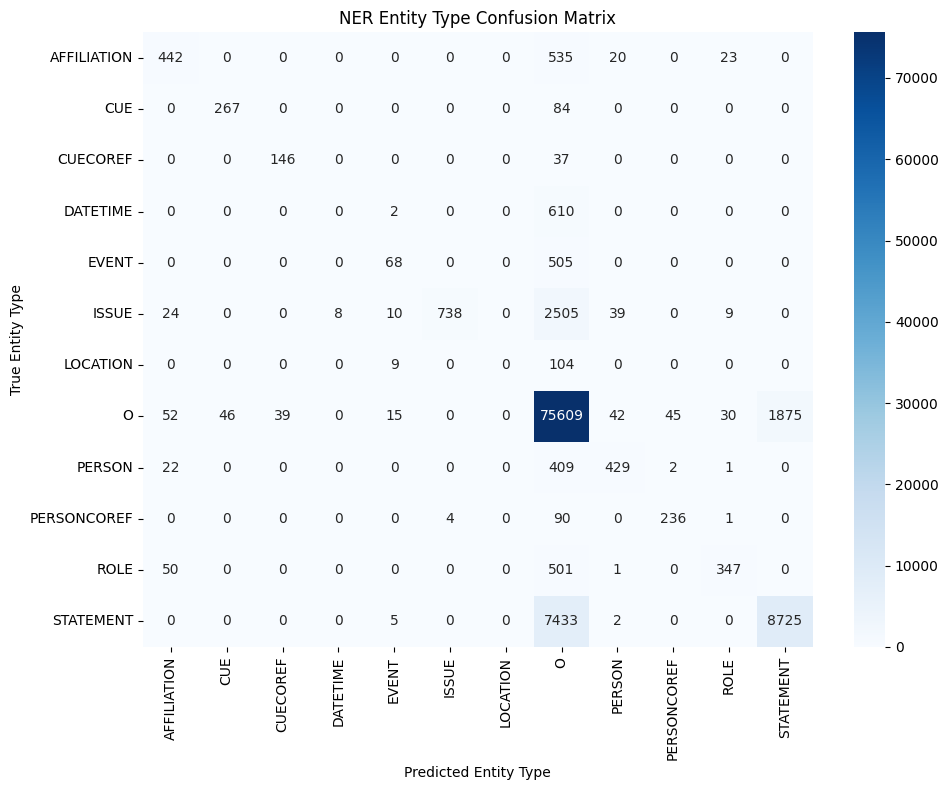

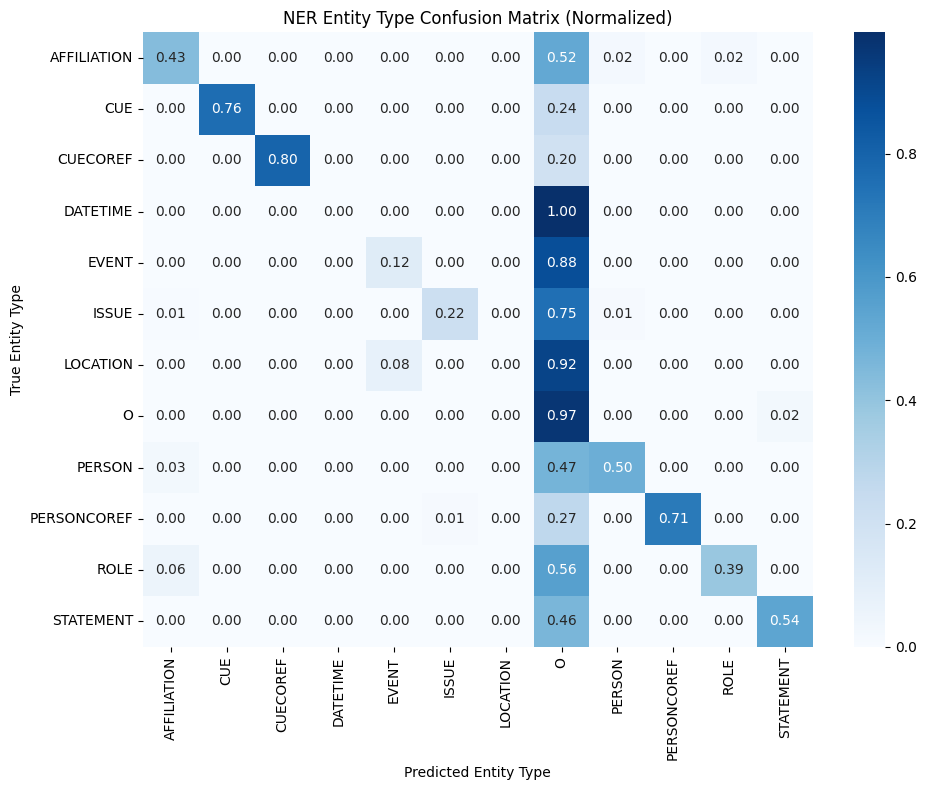

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_entity_level_confusion_matrix(
    y_true,
    y_pred,
    figsize=(10, 8),
    normalize=False,
    title="Entity Type Confusion Matrix",
):
    """
    Generate and plot a confusion matrix at the entity type level
    (ignoring B-, I-, etc. prefixes).

    Parameters:
    -----------
    y_true : list
        List of true label sequences
    y_pred : list
        List of predicted label sequences
    figsize : tuple, default=(10, 8)
        Figure size for the plot
    normalize : bool, default=False
        Whether to normalize the confusion matrix
    title : str
        Title for the confusion matrix plot
    """

    # Extract entity types (removing B-, I-, prefixes)
    def extract_entity_types(tags):
        entity_types = []
        for tag in tags:
            if tag == "O":
                entity_types.append("O")
            else:
                # Split by hyphen and take the second part (the entity type)
                parts = tag.split("-", 1)
                if len(parts) > 1:
                    entity_types.append(parts[1])
                else:
                    entity_types.append(tag)
        return entity_types

    # Flatten and convert to entity types
    y_true_flat = list(chain.from_iterable(y_true))
    y_pred_flat = list(chain.from_iterable(y_pred))

    y_true_types = extract_entity_types(y_true_flat)
    y_pred_types = extract_entity_types(y_pred_flat)

    # Get unique entity types
    unique_types = sorted(set(y_true_types) | set(y_pred_types))

    # Create confusion matrix
    cm = confusion_matrix(y_true_types, y_pred_types, labels=unique_types)

    # Normalize if requested
    if normalize:
        cm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]
        fmt = ".2f"
    else:
        fmt = "d"

    # Plot
    plt.figure(figsize=figsize)
    sns.heatmap(
        cm,
        annot=True,
        fmt=fmt,
        cmap="Blues",
        xticklabels=unique_types,
        yticklabels=unique_types,
    )
    plt.title(title)
    plt.ylabel("True Entity Type")
    plt.xlabel("Predicted Entity Type")
    plt.tight_layout()

    return plt.gcf()  # Return the figure for display or saving
# Create and display entity-level confusion matrix
## Entity non normalized adalah = menampilkan nilai absolut (jumlah token) di setiap sel confusion matrix — berguna untuk melihat berapa banyak contoh sebenarnya.
fig = plot_entity_level_confusion_matrix(
    y_test_cleaned,
    y_pred,
    normalize=False,
    title="NER Entity Type Confusion Matrix"
)## TODO Implementasikan pemanggilan fungsi plot_entity_level_confusion_matrix untuk menampilkan confusion matrix tanpa normalisasi dan judul "NER Entity Type Confusion Matrix"

## Entity normalized adalah = menampilkan persentase (proporsi) di setiap sel confusion matrix — berguna untuk melihat seberapa sering model benar atau salah dalam memprediksi setiap jenis entitas relatif terhadap jumlah sebenarnya.
# Create and display normalized entity-level confusion matrix
fig = plot_entity_level_confusion_matrix(
    y_test_cleaned,
    y_pred,
    normalize=True,
    title="NER Entity Type Confusion Matrix (Normalized)"
)## TODO Implementasikan pemanggilan fungsi plot_entity_level_confusion_matrix untuk menampilkan confusion matrix dengan normalisasi dan judul "NER Entity Type Confusion Matrix (Normalized)"